In [92]:
import numpy as np                                          # Μαθηματική/αριθμητική βιβλιοθήκη
import scipy.io.wavfile as wav                              # Βιβλιοθήκη ανάγνωσης/εγγραφής ήχου
import matplotlib.pyplot as plt                             # Βιβλιοθήκη απεικονίσεων

## Άσκηση - Πώς καταλαβαίνει το κινητό μας τηλέφωνο πότε μιλάμε και πότε όχι?

Μόνο και μόνο με τις έννοιες της *ενέργειας* και του *ρυθμού διελεύσεων από το μηδέν* ενός σήματος, μπορείτε να δείτε μερικές εφαρμογές όπως η
<center><font size=6>
Aνίχνευση δραστηριότητας ομιλίας - voice activity detection.
</center>
<font size=4>
Αλγόριθμοι που υλοποιούν τέτοιες εφαρμογές υπάρχουν σε κάθε κινητό τηλέφωνο, όπως επίσης και σε συστήματα αναγνώρισης ομιλίας όπως η Siri, το Google Assistant, και η Amazon Alexa, αλλά και σε συστήματα επικοινωνιών όπως το Zoom, το Skype, και το Microsoft Teams.

Μια *ιδιαίτερα* απλοϊκή υλοποίηση ενός τέτοιου αλγορίθμου είναι η εξής :
- Διαβάζετε ένα αρχείο ομιλίας στην Python που σας δίνεται. Μόλις το διαβάσετε, γίνεται μια **ακολουθία διακριτού χρόνου** $s[n]$, δηλ. ένα διάνυσμα δειγμάτων.
- **Τμηματοποιείτε** το σήμα σε διαδοχικά **παράθυρα (frames)** σταθερού μήκους $T$ δειγμάτων, απομονώνοντας κάθε φορά ένα κομμάτι του μέσω array slicing.
- Για κάθε frame υπολογίζετε **δύο** χαρακτηριστικά διακριτού χρόνου: την **RMS ενέργειά** του και τον **ρυθμό διελεύσεων από το μηδέν (ZCR)**.
- Με βάση τις τιμές αυτές (και μια κατάλληλη **στατιστική απόφασης**), αποφασίζετε αν το frame περιέχει ομιλία ή όχι.
- Προχωράτε στο επόμενο frame και επαναλαμβάνετε, ως το τέλος του σήματος.

Γιατί δυο χαρακτηριστικά και όχι μόνο η ενέργεια; Γιατί η ενέργεια από μόνη της μερικές φορές "χάνει" τα **άφωνα** σύμφωνα (π.χ. /s/, /f/), που έχουν χαμηλή ενέργεια αλλά υψηλό ZCR. Ο συνδυασμός τους δίνει καλύτερο ανιχνευτή.

Ερωτήματα που προκύπτουν από την ανάγνωση του παραπάνω αλγορίθμου:

(α') Πόσο είναι το μήκος του παραθυροποιημένου σήματος (frame); Μια τιμή κοντά στα $T = 0.03 \cdot F_s$ δείγματα (δηλ. $30$ ms) είναι καλή. Δεν υπάρχει βέλτιστο μήκος, υπάρχουν trade-offs είτε είναι μεγάλο είτε μικρό.

(β') Πόση απόσταση θα έχουν τα διαδοχικά frames μεταξύ τους; Στην πράξη, θα πρέπει όχι απλά να είναι διαδοχικά, αλλά να έχουν και κάποιο *ποσοστό επικάλυψης*. Για τους δικούς μας σκοπούς, θα χρησιμοποιήσουμε $50\%$ επικάλυψη, δηλ. τα frames θα έχουν κατά $50\%$ όμοιο περιεχόμενο με το προηγούμενο και το επόμενό τους.

(γ') Πώς αποφασίζουμε με βάση την **ενέργεια ΚΑΙ τον ZCR** αν το εκάστοτε frame είναι τμήμα ομιλίας; Αυτή είναι μια ερώτηση που δέχεται αρκετές απαντήσεις - προσεγγίσεις. Μια απλή ιδέα: στην αρχή του σήματος υπάρχουν μερικά δευτερόλεπτα σιωπής. Αν εκτιμήσουμε σε αυτά τη "συμπεριφορά" (μέση τιμή & τυπική απόκλιση) και της ενέργειας και του ZCR, μπορούμε να ορίσουμε με βάση αυτές μια **στατιστική απόφασης**. Παρακάτω θα δούμε **δύο εναλλακτικές** τέτοιες στατιστικές και θα σας ζητηθεί να τις αξιολογήσετε.

Θα δουλέψουμε **εξ ολοκλήρου στο διακριτό χρόνο**: το σήμα ομιλίας που σας δίνουμε είναι *ψηφιακό* και όταν το διαβάζετε στην `Python` γίνεται μια ακολουθία δειγμάτων $s[n]$, αποθηκευμένη σε ένα διάνυσμα.

Για ένα frame $x[n]$ με $N$ δείγματα ($n = 0, 1, \dots, N-1$), θα χρησιμοποιήσουμε την **RMS ενέργεια** (Root Mean-Square), που ορίζεται στο διακριτό χρόνο ως

$$\mathrm{RMS}_{\text{energy}} = \sqrt{\frac{1}{N}\sum_{n=0}^{N-1} x^2[n]}$$

δηλαδή την τετραγωνική ρίζα της **μέσης ισχύος** του frame. Ας φτιάξουμε μια απλή συνάρτηση που την υπολογίζει.

In [93]:
def rms_energy(x):
    """RMS ενέργεια ενός frame διακριτού χρόνου x[n]: sqrt( (1/N) * Σ x[n]^2 )."""
    x = np.asarray(x, dtype=float)
    if x.size == 0:
        return 0.0
    return np.sqrt(np.mean(x**2))

# Test:
print(rms_energy(np.array([3, 4])))  # πρέπει να πάρετε 3.5355339059327378  (= sqrt((9+16)/2))

3.5355339059327378


Το δεύτερο χαρακτηριστικό μας είναι ο **Ρυθμός Διελεύσεων από το Μηδέν** (Zero-Crossing Rate, ZCR).

Μια **διέλευση από το μηδέν** (zero-crossing) σε ένα σήμα διακριτού χρόνου $x[n]$ συμβαίνει όποτε δυο **διαδοχικά** δείγματα έχουν **αντίθετο πρόσημο**, δηλαδή όποτε το σήμα "περνάει" τον οριζόντιο άξονα ανάμεσα στα δείγματα $n-1$ και $n$.

Ορίζουμε πρώτα τη **συνάρτηση προσήμου**:

$$\operatorname{sgn}(x[n]) = \begin{cases} +1, & x[n] \ge 0 \\ -1, & x[n] < 0 \end{cases}$$

Τότε το **πλήθος** των διελεύσεων από το μηδέν μέσα σε ένα frame $N$ δειγμάτων είναι

$$Z = \frac{1}{2}\sum_{n=1}^{N-1}\bigl|\operatorname{sgn}(x[n]) - \operatorname{sgn}(x[n-1])\bigr|$$

Για να μην εξαρτάται η τιμή από το μήκος του frame, **κανονικοποιούμε** διαιρώντας με το πλήθος $N-1$ των ζευγών γειτονικών δειγμάτων:

$$\boxed{\;\mathrm{ZCR} = \dfrac{Z}{N-1} = \frac{1}{2(N-1)}\sum_{n=1}^{N-1}\bigl|\operatorname{sgn}(x[n]) - \operatorname{sgn}(x[n-1])\bigr| \in [0, 1]\;}$$

Ο ZCR είναι ένας **έμμεσος δείκτης του κυρίαρχου συχνοτικού περιεχομένου**: υψηλός ZCR σημαίνει έντονο υψίσυχνο/θορυβώδες περιεχόμενο (άφωνα σύμφωνα όπως /s/, /f/), ενώ χαμηλός ZCR σημαίνει χαμηλόσυχνο/έμφωνο περιεχόμενο (φωνήεντα). Πρόχειρα, για ένα ημιτονικό σήμα συχνότητας $f$ που δειγματοληπτείται στα $F_s$, ισχύει $\mathrm{ZCR}\cdot F_s \approx 2f$.

In [94]:
def zero_crossing_rate(x):
    """ZCR ενός frame διακριτού χρόνου x[n]: πλήθος αλλαγών προσήμου, κανονικοποιημένο στο [0,1]."""
    x = np.asarray(x, dtype=float)
    if x.size < 2:
        return 0.0
    s = np.sign(x)            # πρόσημο κάθε δείγματος: +1, 0 ή -1
    s[s == 0] = 1            # σύμβαση: τα ακριβώς-μηδενικά δείγματα τα θεωρούμε θετικά (+1)
    crossings = np.sum(np.abs(np.diff(s))) / 2.0   # πλήθος αλλαγών προσήμου (κάθε αλλαγή δίνει |διαφορά|=2)
    return crossings / (x.size - 1)                 # κανονικοποίηση -> ρυθμός στο [0,1]

# Test:
print(zero_crossing_rate(np.array([1, -1, 1, -1])))  # πρέπει να πάρετε 1.0  (αλλάζει πρόσημο σε κάθε βήμα = 2/2 = 1.0)

1.0


Πριν πάμε στο πλήρες σήμα, ας καταλάβουμε τι συμβαίνει με ένα ελεγχόμενο **toy-παράδειγμα**. Έστω ότι το σήμα ομιλίας διακριτού χρόνου που διαβάζουμε είναι η ακολουθία αριθμών που είναι αποθηκευμένη στο διάνυσμα ```x``` παρακάτω. Ας τη δούμε.

Το σήμα ομιλίας διακριτού χρόνου είναι το x = [ 1.   0.5  1.2 -1.7  2.4 -0.3 -1.1  0.6 -0.9 -1.3]


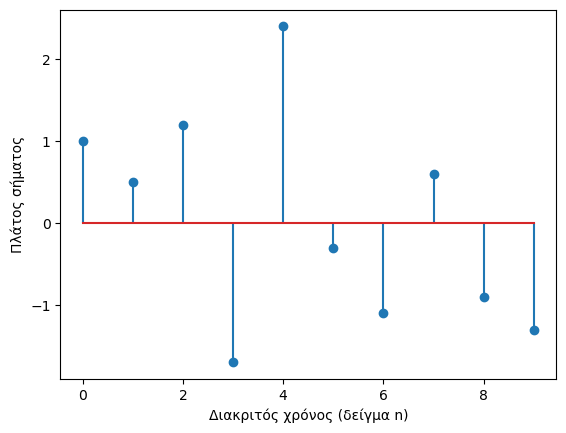

In [95]:
x = np.asarray([1, 0.5, 1.2, -1.7, 2.4, -0.3, -1.1, 0.6, -0.9, -1.3])  # τυχαίο σήμα - υποτίθεται σήμα ομιλίας

print(f"Το σήμα ομιλίας διακριτού χρόνου είναι το x = {x}")      # βλέπουμε τις τιμές του
plt.stem(np.arange(0, 10), x)                                    # τυπώνουμε τις τιμές του
plt.xlabel('Διακριτός χρόνος (δείγμα n)')                        # ομορφαίνουμε
plt.ylabel('Πλάτος σήματος')                                     # ομορφαίνουμε
plt.show()

Οι τιμές που βλέπετε αποτελούν **δείγματα διακριτού χρόνου** $x[n]$. Ας υποθέσουμε ότι θέλουμε να υπολογίσουμε την ενέργεια (και τον ZCR) ανά $N=4$ δείγματα. Τότε χωρίζουμε το σήμα σε διαδοχικές, **επικαλυπτόμενες κατά 50\% (2 δείγματα)** τετράδες δειγμάτων — κάθε τετράδα είναι κι ένα παράθυρο (frame).

Έτσι προκύπτουν (δείτε ξανά το διάνυσμα ```x``` παραπάνω) τέσσερις τετράδες, $(1,\ 0.5,\ 1.2, -1.7),\ (1.2, -1.7,\ 2.4,\ -0.3),\ (2.4, -0.3, -1.1,\ 0.6,),\ (-1.1, 0.6, -0.9, -1.3)$, και για καθεμία θα υπολογίσουμε την RMS ενέργεια και τον ZCR. Θα χρησιμοποιήσουμε μία λίστα (https://www.w3schools.com/python/python_lists.asp) της `Python`, στην οποία μπορούμε να *προσαρτούμε* (append) τις τιμές κάθε παραθύρου.

*(Για να φτάσουμε στα $30$ ms που θέλουμε στο πλήρες σήμα, με $F_s = 16000$ Hz χρειαζόμαστε $T = \mathrm{round}(0.03 \cdot F_s) = 480$ δείγματα ανά frame — αλλά εδώ, στο toy-παράδειγμα, μένουμε στα $N=4$ δείγματα για να δούμε καθαρά τι γίνεται.)*

In [96]:
N = 4        # Μήκος παραθύρου σε δείγματα

# Τμηματοποίηση σε διαδοχικές N-άδες
x1 = x[0:N]           # από 0 ως N-1
x2 = x[N//2:3*N//2]   # από N/2 ως 3*N/2-1
x3 = x[N:2*N]         # από N ως 2N-1
x4 = x[3*N//2:5*N//2] # από 3*N/2 ως 5*N/2-1

E = []  # μια άδεια λίστα για τις RMS ενέργειες των N-άδων
Z = []  # μια άδεια λίστα για τους ZCR των N-άδων
for w in (x1, x2, x3, x4):
    E.append(rms_energy(w))          # RMS ενέργεια του παραθύρου
    Z.append(zero_crossing_rate(w))  # ZCR του παραθύρου

print(f"RMS ενέργειες: E1={E[0]:.6f}, E2={E[1]:.6f}, E3={E[2]:.6f}, E4={E[3]:.6f}")
print(f"ZCR:           Z1={Z[0]:.6f}, Z2={Z[1]:.6f}, Z3={Z[2]:.6f}, Z4={Z[3]:.6f}")
# θα πρέπει να λάβετε:
# RMS ενέργειες: E1=1.181101, E2=1.595306, E3=1.361984, E4=1.008712
# ZCR:           Z1=0.333333, Z2=1.000000, Z3=0.666667, Z4=0.666667

RMS ενέργειες: E1=1.181101, E2=1.595306, E3=1.361984, E4=1.008712
ZCR:           Z1=0.333333, Z2=1.000000, Z3=0.666667, Z4=0.666667


Βλέπετε ότι κάθε τμήμα από το αρχικό σήμα έχει διαφορετική τιμή ενέργειας και ZCR.

Ας επιστρέψουμε τώρα στο πλήρες, πραγματικό παράδειγμα, όπου θα υλοποιήσουμε πιο αυτοματοποιημένα τα παραπάνω.

Η ιδέα είναι η εξής:

- Το σήμα ομιλίας θα αποθηκευτεί σε ένα ``numpy`` array.
- Θα το προσπελαύνουμε ανά 50\% επικαλυπτόμενα τμήματα, με array slicing, όπως στο toy example.
- Για κάθε τμήμα θα υπολογίζουμε την **RMS ενέργειά** του **και** τον **ZCR** του.
- Θα τα αποθηκεύουμε σε δυο arrays, ώστε η $i$-οστή τιμή τους να αντιστοιχεί στο $i$-οστό frame.
- Μόλις μαζέψουμε όλες τις τιμές, θα ορίσουμε μια **στατιστική απόφασης** (με βάση τα frames σιωπής στην αρχή) που θα ταξινομεί κάθε frame ως "speech" ή "non-speech".

Συμπληρώστε τον παρακάτω σκελετό.

In [97]:
# Φόρτωση αρχείου ήχου στην Python (Fs είναι η συχνότητα δειγματοληψίας)
Fs, s = wav.read('./files/speech.wav')

# Επικάλυψη
overlap = 0.5  # 50% επικάλυψη μεταξύ διαδοχικών frames

# Κανονικοποίηση του σήματος σε πλάτη [-1,1] (τεχνική λεπτομέρεια, μην τη λάβετε υπ'όψη)
s = s/np.max(np.abs(s))

# Μήκος frame σε δείγματα (30 ms)
T = round(Fs*0.03)

# ΒΗΜΑ (hop): για 50% επικάλυψη, προχωράμε κατά T/2 δείγματα αντί για T
hop = round(T * (1 - overlap))

# Συνολικό πλήθος δειγμάτων του σήματος
L = len(s)

# Πόσα frames των T δειγμάτων χωράνε με βήμα hop; (κάθε νέο frame ξεκινά hop δείγματα μετά το προηγούμενο)
N = 1 + (L - T) // hop

# Δέσμευση μνήμης
Energy = np.zeros(N)
ZCR = np.zeros(N)
Center = np.zeros(N)   # δείκτης του κεντρικού δείγματος κάθε frame (διακριτός χρόνος)

for i in range(N):

    start = i * hop                      # αρχή του i-οστού frame (μετατοπίζεται κατά hop δείγματα)
    windowed_speech = s[start:start + T] # απομόνωση frame διάρκειας T -> γειτονικά frames επικαλύπτονται κατά 50%

    # RMS ενέργεια του frame
    Energy[i] = rms_energy(windowed_speech)

    # ZCR του frame
    ZCR[i] = zero_crossing_rate(windowed_speech)

    # Κέντρο του frame (σε δείγματα)
    Center[i] = start + T // 2

Τώρα θα ορίσουμε μια **στατιστική απόφασης** για να ξεχωρίσουμε ομιλία από σιωπή. Όπως είπαμε, τα πρώτα $2$ δευτερόλεπτα της ηχογράφησης (δηλ. τα πρώτα $2\cdot F_s$ δείγματα) είναι σιωπή. Θα εκτιμήσουμε από αυτά τη **μέση τιμή** $\mu$ και την **τυπική απόκλιση** $\sigma$ τόσο της ενέργειας όσο και του ZCR, ώστε να ξέρουμε πώς "μοιάζει" η σιωπή. Συμπληρώστε κατάλληλα παρακάτω.

In [98]:
# Πλήθος frames που αντιστοιχούν στα πρώτα 2 δευτερόλεπτα (σιωπή)
No_Silence_Frames = round(2*Fs/hop)

# Στατιστικά της σιωπής για τα δυο χαρακτηριστικά (αγνοούμε το frame 0 που έμεινε μηδενικό)
sil_E = Energy[1:No_Silence_Frames]
sil_Z = ZCR[1:No_Silence_Frames]

muE, sdE = sil_E.mean(), sil_E.std()   # μέση τιμή & τυπική απόκλιση της ΕΝΕΡΓΕΙΑΣ στη σιωπή
muZ, sdZ = sil_Z.mean(), sil_Z.std()   # μέση τιμή & τυπική απόκλιση του ZCR στη σιωπή

print(f"Σιωπή -> Ενέργεια: μ={muE:.4f}, σ={sdE:.4f}")
print(f"Σιωπή -> ZCR:      μ={muZ:.4f}, σ={sdZ:.4f}")

Σιωπή -> Ενέργεια: μ=0.0022, σ=0.0165
Σιωπή -> ZCR:      μ=0.0010, σ=0.0052


#### Στατιστική A — μέγιστο από δύο z-scores

Για κάθε frame $i$ μετράμε **πόσες τυπικές αποκλίσεις πάνω από τη σιωπή** βρίσκονται η ενέργεια και ο ZCR (δηλ. τα *z-scores* ως προς τη σιωπή):

$$z_E[i] = \frac{E[i] - \mu_E}{\sigma_E}, \qquad z_Z[i] = \frac{Z[i] - \mu_Z}{\sigma_Z}$$

και ορίζουμε τη στατιστική

$$\Psi[i] = \max\bigl(z_E[i],\ z_Z[i]\bigr)$$

Αποφασίζουμε **ομιλία** όταν $\Psi[i] > \tau$ (π.χ. $\tau = 3$, δηλ. έναν "κανόνα 3 σίγμα").

Η λογική: τα **έμφωνα** τμήματα (φωνήεντα) έχουν υψηλή ενέργεια → μεγάλο $z_E$. Τα **άφωνα** σύμφωνα (/s/, /f/) έχουν χαμηλή ενέργεια αλλά υψηλό ZCR → μεγάλο $z_Z$. Το $\max$ "πιάνει" και τις δυο περιπτώσεις.

In [99]:
tau = 3.0

zE = (Energy - muE) / (sdE + 1e-12)   # z-score της ενέργειας ως προς τη σιωπή
zZ = (ZCR - muZ) / (sdZ + 1e-12)      # z-score του ZCR ως προς τη σιωπή

Psi = np.maximum(zE, zZ)              # η στατιστική A
D_A = (Psi > tau).astype(float)       # απόφαση: 1 = ομιλία, 0 = σιωπή

#### Στατιστική B — ενέργεια ως πρωτεύον κριτήριο, ZCR για επέκταση ορίων (Rabiner–Sambur)

Μια πιο "κλασική" προσέγγιση (στο πνεύμα των Rabiner & Sambur, 1975 - https://web.ece.ucsb.edu/Faculty/Rabiner/ece259/Reprints/078_endpoint%20detection.pdf):

1. **Πρωτεύουσα απόφαση με ενέργεια**: θεωρούμε ομιλία τα frames με $$E[i] > \mu_E + k_E\,\sigma_E$$ (π.χ. $k_E = 3$). Έτσι εντοπίζουμε με ασφάλεια τα δυνατά, έμφωνα τμήματα — τον "κορμό" της ομιλίας.

2. **Επέκταση ορίων με ZCR**: τα άφωνα σύμφωνα στην *αρχή/τέλος* των λέξεων έχουν χαμηλή ενέργεια και θα χάνονταν. Γι' αυτό, ξεκινώντας από τα όρια που βρήκε η ενέργεια, **επεκτείνουμε** την περιοχή ομιλίας προς τα γειτονικά frames όσο αυτά έχουν υψηλό ZCR, $$Z[i] > \mu_Z + k_Z\,\sigma_Z$$ (π.χ. $k_Z = 2$).

In [100]:
kE, kZ = 3.0, 2.0
E_thresh = muE + kE * sdE     # κατώφλι ενέργειας
zcr_thresh = muZ + kZ * sdZ   # κατώφλι ZCR

# 1) Πρωτεύουσα απόφαση με βάση την ενέργεια
D_B = (Energy > E_thresh).astype(float)

# 2) Επέκταση προς γειτονικά frames με υψηλό ZCR (άφωνα σύμφωνα στα άκρα των λέξεων)
changed = True
while changed:
    changed = False
    for i in range(N):
        if D_B[i] == 0 and ZCR[i] > zcr_thresh:
            neighbour_is_speech = (i > 0 and D_B[i-1] == 1) or (i < N-1 and D_B[i+1] == 1)
            if neighbour_is_speech:
                D_B[i] = 1
                changed = True

Τώρα μπορούμε να "ενώσουμε" τις εκτιμήσεις μας και να απεικονίσουμε το αποτέλεσμα **και για τις δυο στατιστικές**, ώστε να τις συγκρίνουμε. Ο άξονας είναι σε **δείγματα διακριτού χρόνου** $n$.

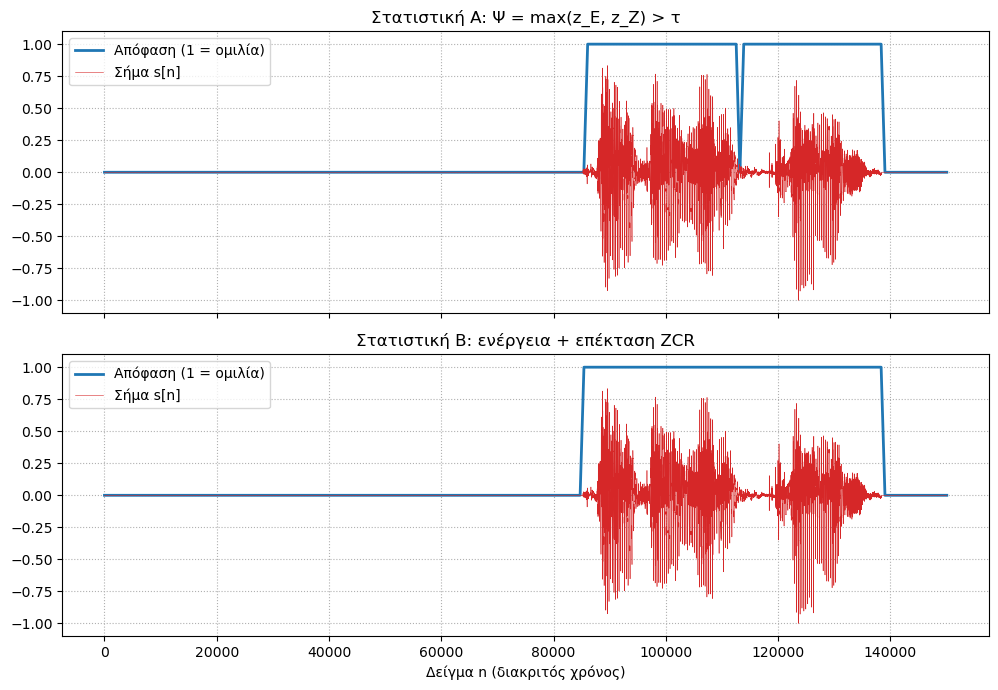

In [101]:
n = np.arange(L)   # άξονας διακριτού χρόνου (δείγματα)

fig, ax = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

for a, D, name in [(ax[0], D_A, "Στατιστική A: Ψ = max(z_E, z_Z) > τ"),
                   (ax[1], D_B, "Στατιστική B: ενέργεια + επέκταση ZCR")]:
    Din = np.interp(n, Center, D)                          # γραμμική παρεμβολή στην ανάλυση των δειγμάτων
    a.plot(n, Din, color="tab:blue", linewidth=2, label="Απόφαση (1 = ομιλία)")
    a.plot(n, s, color="tab:red", linewidth=0.4, label="Σήμα s[n]")
    a.set_title(name)
    a.grid(linestyle=":")
    a.legend(loc="upper left")

ax[1].set_xlabel("Δείγμα n (διακριτός χρόνος)")
plt.tight_layout()
plt.show()

Αν τα κάνετε όλα σωστά, θα πάρετε κάτι **στο πνεύμα** του παρακάτω σχήματος (ενδεικτική έξοδος VAD):

<p style="text-align: center"><img src="./files/output.png" width="800"></p>

### Ερώτηση: Συγκρίνετε τις δύο στατιστικές (A και B).

- Ποιά δουλεύει καλύτερα, έστω και σε αυτό το απλό παράδειγμα; Γράψτε τα συμπεράσματά σας παρακάτω.

### Απάντηση:

Βλέπουμε ότι η στρατηγική Α χάνει ένα frame χαμηλής ενέργειας, ενώ η στρατηγική Β το "πιάνει".

α) Επαναλάβετε την παραπάνω άσκηση με χρήση της δικής σας φωνής! Ηχογραφήστε τον εαυτό σας, για 5-7 δευτερόλεπτα, λέγοντας μια τυχαία πρόταση μεγάλης διάρκειας αλλά <span style="font-size:1.5em;">κρατώντας τα δυο πρώτα δευτερόλεπτα σιωπηλά</span>.

Χρησιμοποιήστε συχνότητα δειγματοληψίας $16000$ Hz, και μονοκαναλική ηχογράφηση. Προτεινόμενο πρόγραμμα ηχογράφησης: Audacity (https://www.audacityteam.org/)

Το παραγόμενο αρχείο πρέπει να μπει στον ίδιο κατάλογο με το παρόν .ipynb αρχείο, σε έναν υποκατάλογο ``files``.

<span style="font-size:1em;">Αν δεν το καταφέρετε, χρησιμοποιήστε το αρχείο `au-bout-du-telephone.wav` που σας δίνεται.</span>

Για να μην επαναλαμβάνουμε τον ίδιο κώδικα, ας μαζέψουμε όλη τη διαδικασία (τμηματοποίηση → RMS ενέργεια & ZCR ανά frame → στατιστικές A και B → γράφημα) σε **μία συνάρτηση** ```run_vad```, και ας την καλέσουμε για κάθε αρχείο.

C:\Users\kafge\AppData\Local\Temp\ipykernel_30472\3396734730.py:7: WavFileWarning: Chunk (non-data) not understood, skipping it.
  Fs, s = wav.read(path)


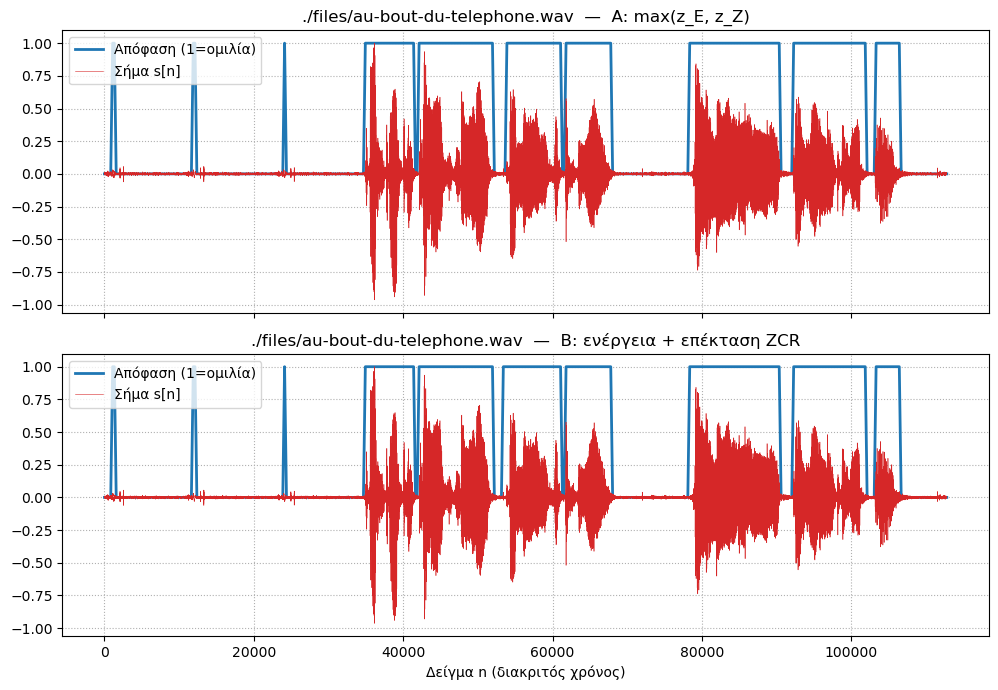

In [ ]:
def run_vad(path, frame_ms=30.0, silence_sec=2.0, tau=3.0, kE=3.0, kZ=2.0, overlap=0.5):
    """
    Ανιχνευτής δραστηριότητας ομιλίας διακριτού χρόνου, με RMS ενέργεια + ZCR.
    Υπολογίζει και σχεδιάζει τις αποφάσεις των δύο στατιστικών (A και B).
    Επιστρέφει: Energy, ZCR, D_A, D_B.
    """
    Fs, s = wav.read(path)
    s = s / np.max(np.abs(s))                 # κανονικοποίηση σε [-1,1]

    L = len(s)                                # Συνολικό πλήθος δειγμάτων του σήματος
    T = round(Fs * frame_ms / 1000.0)         # μήκος frame σε δείγματα
    hop = round(T * (1 - overlap))            # Πόσα frames των T δειγμάτων χωράνε με βήμα hop; (κάθε νέο frame ξεκινά hop δείγματα μετά το προηγούμενο)
    N = 1 + (L - T) // hop                    # πλήθος επικαλυπτόμενων frames

    Energy = np.zeros(N)
    ZCR = np.zeros(N)
    Center = np.zeros(N)

    for i in range(1, N):

        start = i * hop                        # αρχή του i-οστού frame (μετατοπίζεται κατά hop δείγματα)
        w = s[start:start + hop]               # απομόνωση frame διάρκειας T -> γειτονικά frames επικαλύπτονται κατά 50%
        
        Energy[i] = rms_energy(w)
        ZCR[i] = zero_crossing_rate(w)
        Center[i] = round(i*hop + hop/2)

    # Στατιστικά σιωπής
    ns = round(silence_sec * Fs / hop)
    muE, sdE = Energy[1:ns].mean(), Energy[1:ns].std()
    muZ, sdZ = ZCR[1:ns].mean(), ZCR[1:ns].std()

    # Στατιστική A: max των z-scores
    Psi = np.maximum((Energy - muE)/(sdE + 1e-12), (ZCR - muZ)/(sdZ + 1e-12))
    D_A = (Psi > tau).astype(float)

    # Στατιστική B: ενέργεια + επέκταση με ZCR
    D_B = (Energy > muE + kE*sdE).astype(float)
    zt = muZ + kZ*sdZ
    changed = True
    while changed:
        changed = False
        for i in range(N):
            if D_B[i] == 0 and ZCR[i] > zt and ((i > 0 and D_B[i-1] == 1) or (i < N-1 and D_B[i+1] == 1)):
                D_B[i] = 1
                changed = True

    # Γράφημα
    n = np.arange(L)
    fig, ax = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

    for a, D, name in [(ax[0], D_A, "A: max(z_E, z_Z)"), (ax[1], D_B, "B: ενέργεια + επέκταση ZCR")]:
        a.plot(n, np.interp(n, Center, D), color="tab:blue", linewidth=2, label="Απόφαση (1=ομιλία)")
        a.plot(n, s, color="tab:red", linewidth=0.4, label="Σήμα s[n]")
        a.set_title(f"{path}  —  {name}")
        a.grid(linestyle=":")
        a.legend(loc="upper left")
        
    ax[1].set_xlabel("Δείγμα n (διακριτός χρόνος)")
    plt.tight_layout()
    plt.show()

    return Energy, ZCR, D_A, D_B


# Εφαρμογή στο αρχείο au-bout-du-telephone.wav
_ = run_vad('./files/au-bout-du-telephone.wav')

---
---